In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("train.csv")

In [3]:
train.head()

,CoilID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X41,X42,X43,X44,X45,X46,X47,X48,X49,Y
0,487,854.787195,501.088868,414.841484,710.583316,662.072013,656.076977,547.040479,563.653582,495.296785,...,0.201645,0.047960,0.267467,0.052247,-0.893174,0.000000,0.028925,0.000534,0.010797,0.0
1,44,1056.526699,868.083321,622.879982,725.276469,665.235554,647.450550,552.333202,565.105074,493.310075,...,0.644403,0.000000,0.341870,0.153513,25.471899,0.002520,0.033281,0.028349,0.079602,0.0
2,192,1095.648362,668.112517,695.787904,716.773671,662.843475,657.542380,549.863867,546.210823,482.814753,...,0.486502,0.000000,0.202539,0.168192,-25.764196,0.002072,0.033878,0.000000,0.058266,0.0
3,1552,1050.943543,660.340015,440.280245,611.562496,628.081103,561.397721,456.816210,550.103433,378.353283,...,1.198010,0.020787,0.288786,0.329108,1.033840,0.000250,0.045490,0.039004,0.004850,0.0
4,1190,1091.640314,297.363775,842.665620,749.160886,652.992309,615.576656,608.364764,549.756758,487.753140,...,0.237231,0.000841,0.257281,0.112637,-11.130157,0.002376,0.031298,0.003623,0.018434,0.0


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1352 entries, 0 to 1351
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CoilID  1352 non-null   int64  
 1   X1      1352 non-null   float64
 2   X2      1352 non-null   float64
 3   X3      1352 non-null   float64
 4   X4      1352 non-null   float64
 5   X5      1352 non-null   float64
 6   X6      1352 non-null   float64
 7   X7      1352 non-null   float64
 8   X8      1351 non-null   float64
 9   X9      1352 non-null   float64
 10  X10     1346 non-null   float64
 11  X11     1352 non-null   float64
 12  X12     1352 non-null   float64
 13  X13     1352 non-null   float64
 14  X14     1352 non-null   float64
 15  X15     1192 non-null   float64
 16  X16     1346 non-null   float64
 17  X17     1352 non-null   float64
 18  X18     1352 non-null   float64
 19  X19     1352 non-null   float64
 20  X20     1352 non-null   float64
 21  X21     1351 non-null   float64
 22  X22     135

In [5]:
train.shape

(1352, 51)

In [6]:
train.isnull().sum()

CoilID      0
X1          0
X2          0
X3          0
X4          0
X5          0
X6          0
X7          0
X8          1
X9          0
X10         6
X11         0
X12         0
X13         0
X14         0
X15       160
X16         6
X17         0
X18         0
X19         0
X20         0
X21         1
X22         0
X23         6
X24         6
X25         6
X26         7
X27         6
X28         0
X29         0
X30         0
X31         0
X32         0
X33         0
X34         0
X35         0
X36         0
X37         0
X38         0
X39         0
X40         0
X41         0
X42        31
X43         0
X44         0
X45         0
X46         0
X47         0
X48        13
X49         0
Y           0
dtype: int64

In [7]:
train.describe()

,CoilID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X41,X42,X43,X44,X45,X46,X47,X48,X49,Y
count,1352.000000,1352.000000,1352.000000,1352.000000,1352.000000,1352.000000,1352.000000,1352.000000,1351.000000,1352.000000,...,1352.000000,1321.000000,1352.000000,1352.000000,1352.000000,1352.000000,1352.000000,1339.000000,1352.000000,1352.000000
mean,833.515533,1028.915322,575.374555,538.372787,692.576938,649.010832,618.584573,529.241056,528.770054,461.699867,...,0.585886,0.011334,0.281290,0.091495,11.507361,0.002745,0.050913,0.007108,0.064400,0.048817
std,487.420566,108.505011,232.103882,135.288085,56.798904,35.398207,45.602831,46.263179,40.220201,40.600916,...,0.296115,0.017114,0.068455,0.073058,25.004864,0.006660,0.044617,0.012504,0.050905,0.215564
min,1.000000,235.252250,96.755492,124.150450,575.916250,559.272859,529.937396,439.221384,425.413251,343.110465,...,0.077352,0.000000,0.029599,0.000000,-82.672877,0.000000,0.016833,0.000000,0.000000,0.000000
25%,411.250000,1009.279089,405.533242,441.585514,622.213663,625.327743,583.363796,476.813303,520.192858,423.604248,...,0.365881,0.000380,0.244377,0.026073,-1.368777,0.000943,0.039864,0.000000,0.015624,0.000000
50%,824.500000,1071.978233,589.160841,548.035306,724.970407,661.170690,615.240491,547.648095,545.399528,482.412285,...,0.574328,0.002613,0.293164,0.076108,9.177752,0.001644,0.045829,0.001056,0.060336,0.000000
75%,1254.250000,1092.031100,725.766924,632.238363,734.453213,668.054192,659.564239,554.584166,556.334294,488.713960,...,0.797025,0.013933,0.334613,0.143156,24.196605,0.002275,0.051435,0.002679,0.106017,0.000000
max,1691.000000,1124.903234,1148.171484,1026.915778,755.983296,763.257466,742.725523,618.947910,575.312130,505.349388,...,1.377925,0.062637,0.409739,0.329108,120.169658,0.064545,0.424405,0.051150,0.249522,1.000000


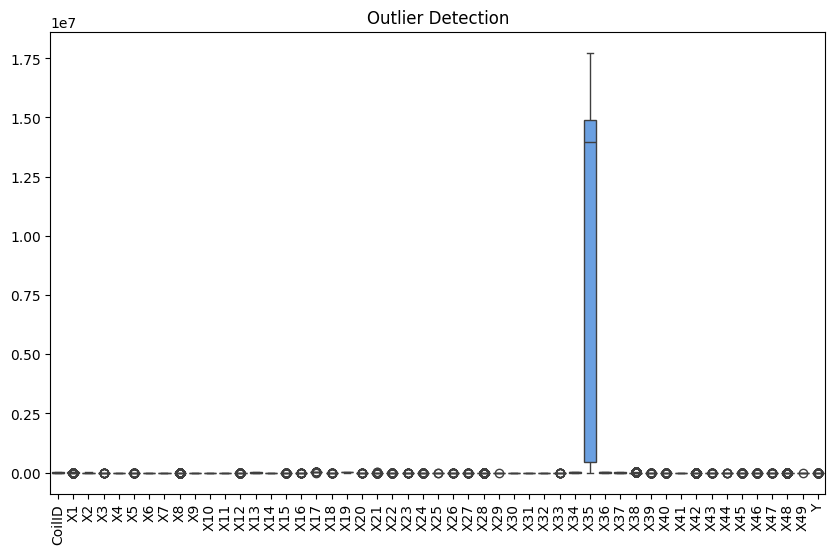

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train.select_dtypes(include=['float', 'int']))
plt.xticks(rotation=90)
plt.title('Outlier Detection')
plt.show()

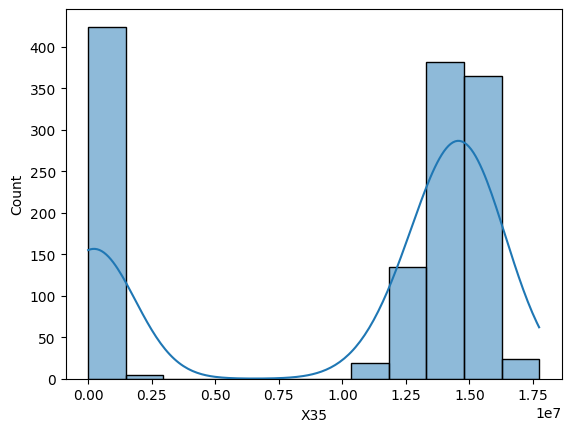

In [9]:
sns.histplot(train['X35'], kde=True)
plt.show()

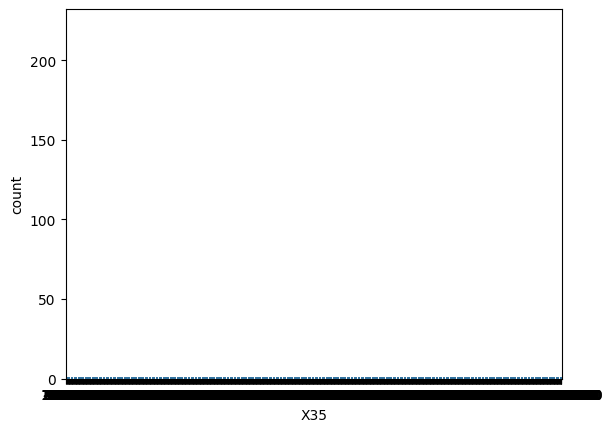

In [10]:
sns.countplot(x='X35', data=train)
plt.show()

In [11]:
corr = train.corr()

<Axes: >

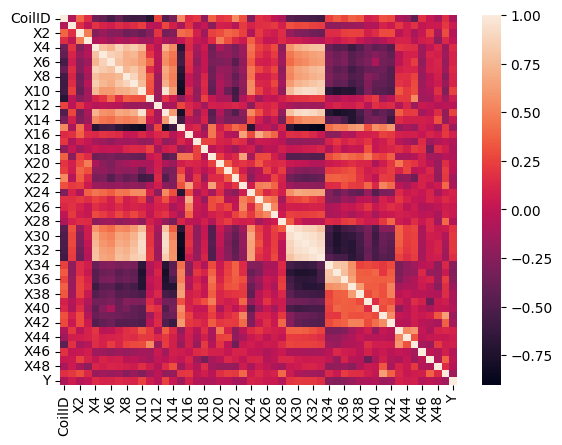

In [12]:
sns.heatmap(corr)